# **Cross Country Workout Data**
*Created by Ryan Sponzilli*

In [52]:
#| echo: false
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import glob

import seasons
import plotting

## Table of Contents
* [1. Introduction](#1-introduction)
    * [1.1 Goals](#11-goals)
    * [1.2 Raw Data](#12-raw-data)
        * [1.2.1 Records](#121-records)
        * [1.2.2 Workouts](#122-workouts)
        * [1.2.3 GPX Tracks](#123-gpx-tracks)
* [2. Exploratory Data Analysis]()
* [3. Data Cleaning](#2-data-cleaning)
    * [3.1 GPX File List]()
        * [3.1.1 Parse Filename]()
        * [3.1.2 Filter Time Period]()
        * [3.1.3 Year & Season Bucketing]()
    * [3.2 Workouts XML]()
        * [3.2.1 Filter Time Period]()
        * [3.2.2 Filter Activity Type]()
    * [3.3 Merge GPX File List with Workout Data]()
    * [3.4 GPX Track Data Extraction]()
        * [3.4.1 Start & Stop Locations]()
        * [3.4.2 Track Line Pause Detection]()
        * [3.4.3 Run Statistics]()
* [4. Route Classification](#3-route-classification)
    * [4.1 Unsupervised Route Clustering]()
    * [4.2 Creating a Route Library]()
    * [4.2 Supervised Route Clustering]()
* [5. Run Type Classification](#4-run-type-classification)
    * [5.1 Run Type Overview]()
    * [5.2 Flagging Doubles]()
    * [5.3 Fixing Accidental Splits]()
    * [5.4 Grouping Workouts]()
* [6. Analysis](#5-analysis)
* [7. Summary](#6-summary)

## 1. Introduction

I ran cross country and track all four years that I was in high school, and I recorded every single run on my Apple Watch. I believe that this is a very unique trove of data that has the potential to be very interesting and very personal.

### 1.1 Goals

* Learn how to work with geospatial data and tools:
    * Learn how to manipulate geospatial data with the `geopandas` library.
    * Learn how to create effective visualizations of geospatial data.
* Develop a data pipeline to ingest the raw data and output a processed dataset ready for analysis and visualization:
    * Use machine learning techniques to perform route geoclustering and route decomposition.
    * Categorize runs into specific types (e.g., workouts, long runs, normal runs).
    * Thoroughly document every decision and assumption made while processing the data.
* Analyze the data to create visually appealing and informative maps and charts:
    * Understand the geographic distribution of my runs.
    * Understand my training regimen and how it evolved over time.
    * Understand how I improved over my four years.

### 1.2 Raw Data

I obtained the raw data by exporting my Apple Health data. This export gave me a 2.23 GB `.xml` file and a folder containing 1,232 `.gpx` files.

#### 1.2.1 Records

The `.xml` file contains a `Record` tag, which contains a data record for a health statistic, such as *ActiveEnergyBurned*, *HeartRate*, or *EnvironmentalAudioExposure*. This will be useful for getting fitness statistics, such as heart rate, VO2 max, and calories burned.

In [ ]:
#| echo: false
df = pd.read_parquet("../data/intermediate/record_data.parquet")
print("Sample of 3 \"Record\" records:")
display(df.sample(3))
print(f"Dataframe Length: {len(df)} Rows")

Sample of 3 "Record" records:


,type,sourceName,sourceVersion,unit,creationDate,startDate,endDate,value,device
3492505,HKQuantityTypeIdentifierActiveEnergyBurned,Ryan’s Apple Watch,6.1,Cal,2019-12-03 09:04:45 -0600,2019-12-03 09:02:35 -0600,2019-12-03 09:03:36 -0600,1.691,"<<HKDevice: 0x3000f8fa0>, name:Apple Watch, ma..."
4620145,HKQuantityTypeIdentifierWalkingAsymmetryPercen...,Ryans IPhone,18.0,%,2024-10-28 17:41:51 -0600,2024-10-28 17:16:18 -0600,2024-10-28 17:20:33 -0600,0.01,"<<HKDevice: 0x3000fe3a0>, name:iPhone, manufac..."
2221301,HKQuantityTypeIdentifierBasalEnergyBurned,Ryan’s Apple Watch,5.1.3,Cal,2019-04-24 17:39:48 -0600,2019-04-24 17:26:00 -0600,2019-04-24 17:27:11 -0600,1.22,"<<HKDevice: 0x3000e3520>, name:Apple Watch, ma..."


Dataframe Length: 4964069 Rows


#### 1.2.2 Workouts
The `.xml` file contains a `Workout` tag, which contains a data record for individual workouts. Not much useful information is provided in these records, just dates, a duration, and the type of activity. The type of activity is the most important field. Since the GPX tracks do not specify what activity they contain, I will need to link them to these records to identifiy which ones correspond to runs, and not to walks, bike rides, or hikes.

In [ ]:
#| echo: false
df = pd.read_parquet("../data/intermediate/workout_data.parquet")
print("Sample of 3 \"Workout\" records:")
display(df.sample(3))
print(f"Dataframe Length: {len(df)} Rows")

Sample of 3 "Workout" records:


,workoutActivityType,duration,durationUnit,sourceName,sourceVersion,creationDate,startDate,endDate,device
75,HKWorkoutActivityTypeRunning,11.94204427798589,min,Ryan’s Apple Watch,5.3,2019-08-27 15:28:46 -0600,2019-08-27 15:15:53 -0600,2019-08-27 15:28:37 -0600,"<<HKDevice: 0x3003e20d0>, name:Apple Watch, ma..."
256,HKWorkoutActivityTypeRunning,10.74744849403699,min,Ryan’s Apple Watch,6.1.1,2020-01-28 15:22:28 -0600,2020-01-28 15:03:02 -0600,2020-01-28 15:22:28 -0600,"<<HKDevice: 0x300022bc0>, name:Apple Watch, ma..."
228,HKWorkoutActivityTypeRunning,29.98319890697797,min,Ryan’s Apple Watch,6.1.1,2019-12-31 08:43:36 -0600,2019-12-31 08:09:52 -0600,2019-12-31 08:43:35 -0600,"<<HKDevice: 0x300022bc0>, name:Apple Watch, ma..."


Dataframe Length: 1460 Rows


#### 1.2.3 GPX Tracks

The `.gpx` files are the most valuable data source. They contain the geometry of the run, which consists of a sequence of latitude and longitude coordinates sampled approximately every second during the run. A single `.gpx` file can contain multiple data layers.

In [ ]:
#| echo: false
gpx_file = glob.glob("../data/raw/workout-routes/*.gpx")[0]
print("GPX File Layers:")
display(gpd.list_layers(gpx_file))

GPX File Layers:


,name,geometry_type
0,waypoints,Point
1,routes,LineString
2,tracks,MultiLineString
3,route_points,Point
4,track_points,Point


<br>

However, only two of the layers contain any data. These are the `tracks` layer and the `track_points` layer. I can load these individually using `geopandas.read_file()`. Most of the columns do not contain any data, but what really matters is the `geometry` column.

In [ ]:
#| echo: false
gdf = gpd.read_file(gpx_file, layer='tracks')
print("\"tracks\" Layer:")
display(gdf)

"tracks" Layer:


,name,cmt,desc,src,link1_href,link1_text,link1_type,link2_href,link2_text,link2_type,number,type,geometry
0,Route 2020-10-06 3:55pm,None,None,None,None,None,None,None,None,None,NaN,None,"MULTILINESTRING ((-88.27857 41.92811, -88.2786..."


<br>

In [ ]:
#| echo: false
gdf = gpd.read_file(glob.glob("../data/raw/workout-routes/*.gpx")[0], layer='track_points')
print("\"track_points\" Layer:")
display(gdf.head(3))
print(f"Dataframe Length: {len(gdf)} Rows")

"track_points" Layer:


,track_fid,track_seg_id,track_seg_point_id,ele,time,magvar,geoidheight,name,cmt,desc,...,sym,type,fix,sat,hdop,vdop,pdop,ageofdgpsdata,dgpsid,geometry
0,0,0,0,241.046722,2020-10-06 20:21:07+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-88.27857 41.92811)
1,0,0,1,240.653961,2020-10-06 20:21:07+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-88.27862 41.9281)
2,0,0,2,240.572311,2020-10-06 20:21:08+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-88.27863 41.9281)


Dataframe Length: 2007 Rows


The `track_points` layer is more useful, since it provides a more granular representation of the data. For each point, it gives a coordinate, timestamp, and elevation. These can be used to derive statistics such as elapsed distance, running pace, elevation change, and later, for route geoclustering.

The data for a gpx track line plotted on a map:


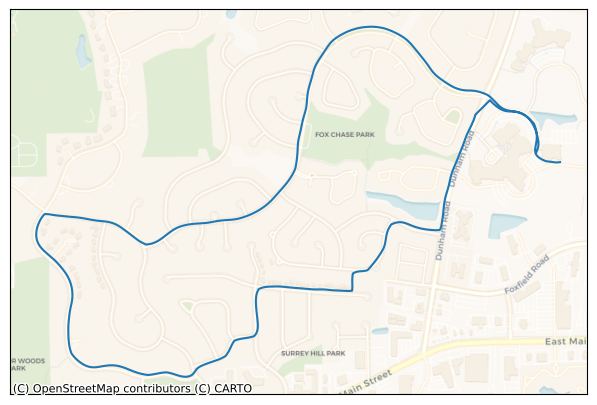

In [91]:
#| echo: false
fig, ax = plt.subplots(figsize=(12, 5))
print("The data for a gpx track line plotted on a map:")
plotting.plot_map(gdf, ax)
plt.show()

## 2. Exploratory Data Analysis
EDA

## 3. Data Cleaning
Data Cleaning

### 3.1 GPX File List

In [48]:
#| echo: false
seasons.seasons

,year,season,start_date,end_date
0,Freshman,Summer Training,2019-06-10 00:00:00-05:00,2019-08-12 00:00:00-05:00
1,Freshman,XC Season,2019-08-12 00:00:00-05:00,2019-11-08 00:00:00-06:00
2,Freshman,Winter Training,2019-11-08 00:00:00-06:00,2020-01-27 00:00:00-06:00
3,Freshman,Track Season,2020-01-27 00:00:00-06:00,2020-05-02 00:00:00-05:00
4,Sophomore,Summer Training,2020-05-02 00:00:00-05:00,2020-08-10 00:00:00-05:00
5,Sophomore,XC Season,2020-08-10 00:00:00-05:00,2020-10-19 00:00:00-05:00
6,Sophomore,Winter Training,2020-10-19 00:00:00-05:00,2021-04-05 00:00:00-05:00
7,Sophomore,Track Season,2021-04-05 00:00:00-05:00,2021-06-10 00:00:00-05:00
8,Junior,Summer Training,2021-06-10 00:00:00-05:00,2021-08-09 00:00:00-05:00
9,Junior,XC Season,2021-08-09 00:00:00-05:00,2021-10-25 00:00:00-05:00


In [49]:
#| echo: false
df = pd.read_parquet("../data/intermediate/track_info_parsed.parquet")
print(f"Dataframe Length: {len(df)} Rows")
df.head()

Dataframe Length: 1128 Rows


,track_file,track_file_datetime,track_file_date,year,season
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,Freshman,Summer Training
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,Freshman,Summer Training
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,Freshman,Summer Training
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-14 14:56:00-05:00,2019-06-14,Freshman,Summer Training
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-14 17:15:00-05:00,2019-06-14,Freshman,Summer Training


### 3.2 Workouts XML

In [57]:
#| echo: false
df = pd.read_parquet("../data/parsed/workout_data.parquet")
print(f"Dataframe Length: {len(df)} Rows")
df.head()

Dataframe Length: 1268 Rows


,workoutActivityType,creation_datetime,start_datetime,end_datetime,duration,durationUnit
0,HKWorkoutActivityTypeRunning,2019-06-10 06:46:26-06:00,2019-06-10 05:57:37-06:00,2019-06-10 06:46:11-06:00,48.564544,min
1,HKWorkoutActivityTypeRunning,2019-06-11 06:32:34-06:00,2019-06-11 05:58:59-06:00,2019-06-11 06:32:25-06:00,33.435890,min
2,HKWorkoutActivityTypeRunning,2019-06-12 06:35:28-06:00,2019-06-12 05:53:26-06:00,2019-06-12 06:35:17-06:00,31.116127,min
3,HKWorkoutActivityTypeRunning,2019-06-13 06:40:16-06:00,2019-06-13 05:54:03-06:00,2019-06-13 06:40:04-06:00,46.021483,min
4,HKWorkoutActivityTypeCycling,2019-06-14 13:56:26-06:00,2019-06-14 10:00:41-06:00,2019-06-14 13:56:10-06:00,60.731609,min


### 3.3 Merge GPX File List with Workouts XML

In [51]:
#| echo: false
df = pd.read_parquet("../data/intermediate/track_info_merged.parquet")
print(f"Dataframe Length: {len(df)} Rows")
df.head()

Dataframe Length: 1033 Rows


,track_file,track_file_datetime,track_file_date,year,season
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,Freshman,Summer Training
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,Freshman,Summer Training
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,Freshman,Summer Training
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,Freshman,Summer Training
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,Freshman,Summer Training


### 3.4 GPX Track Data Extraction

## 4. Route Classification
Route Classification

## 5. Run Type Classification
Run Type Classification

## 6. Analysis
Analysis

## 7. Summary
Summary